# Script XA DSA
This notebook imports necessary libraries and data from Excel files to work with ...

In [1]:
from xa_dose_analysis import dt_ids7_export_module as bh_utils
from xa_dose_analysis import mapping_module as bh_map
from xa_dose_analysis import plot_module as bh_plot
import pandas as pd



# Import the DoseTrack data:
root_folder1 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/"
root_folder2 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2024/"
root_folder3 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2025/"
root_folder4 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DT - 2026/"
df_ids7_2025 = bh_utils.import_excel_files_to_dataframe(root_folder1)
df_ids7_2024 = bh_utils.import_excel_files_to_dataframe(root_folder2)
df_ids7_2023 = bh_utils.import_excel_files_to_dataframe(root_folder3)
df_ids7_2026 = bh_utils.import_excel_files_to_dataframe(root_folder4)
# Merge the dataframes for all years:
df_dt = pd.concat([df_ids7_2025, df_ids7_2024, df_ids7_2023, df_ids7_2026], ignore_index=True)


# Import the IDS7 data:
root_folder1 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/IDS7/2023/"
root_folder2 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/IDS7/2024/"
root_folder3 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/IDS7/2025/"
root_folder4 = "/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/IDS7 - 2026/"  
df_dt_2025 = bh_utils.import_excel_files_to_dataframe(root_folder1)
df_dt_2024 = bh_utils.import_excel_files_to_dataframe(root_folder2)
df_dt_2023 = bh_utils.import_excel_files_to_dataframe(root_folder3)
df_dt_2026 = bh_utils.import_excel_files_to_dataframe(root_folder4)
# Merge the dataframes for all years:
df_ids7 = pd.concat([df_dt_2025, df_dt_2024, df_dt_2023, df_dt_2026], ignore_index=True)

del df_ids7_2025, df_ids7_2024, df_ids7_2023, df_ids7_2026, df_dt_2025, df_dt_2024, df_dt_2023, df_dt_2026

Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-12 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-08 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-01 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-11 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-06 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-04 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-10 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-07 - OUS.xlsx...
Reading /run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/DoseTrack - Serienivå/2023/2023-05 - OUS.xlsx...
Reading /run/media/

In [2]:
# Run all cleanups, filters and checks:
df_ids7 = bh_utils.run_all_cleanup_filters_and_checks(df_ids7, df_dt, True)
# Merge the dataframes:
data = bh_utils.merge_ids7_dt(df_ids7, df_dt, True)

Dropping unnecessary column: Prioritet- og lesemerkeikon
Dropping unnecessary column: Lagt til i demonstrasjon-ikon
Dropping unnecessary column: Status
Number of rows with NaT in the column "Bestilt dato og tidspunkt": 3627
Number of cancelled procedures: 2542
Number of non-human subjects: 205
Number of rows with invalid accession number: 19
1673      NNUL000009420412
6847      NBOU000007962455
6848      NBOU000007962455
9090      NORRAD0004436111
9091      NORRAD0004436111
9093      NORRAD0004443460
12153     NNRA000008470721
12154     NNRA000008470721
15681     NNRA000008253963
24728     NORRAD0004440016
42560     NNRA000009433721
55625     NNUL000009507772
55626     NNUL000009507772
55627     NNUL000009612281
62922     NBOU000012935221
73966     NNRA000009532398
73967     NNRA000009578608
86689     NBOU000017196075
116978    NBOU000022865037
Name: Henvisnings-ID, dtype: str
1277 entries was found matching the old siemens PACS format (7 characters long with only numbers.)
These will 

In [3]:
data.to_pickle("/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/data/data_cardiac.pkl")

In [1]:
from xa_dose_analysis import dt_ids7_export_module as bh_utils
from xa_dose_analysis import mapping_module as bh_map
from xa_dose_analysis import plot_module as bh_plot
import pandas as pd
data = pd.read_pickle("/run/media/bhosteras/PRIVATE_USB/Intervensjon Doser/data/data_cardiac.pkl")

In [ ]:
# Print all unique elements in Modality Room, sorted alphabetically:
print("Unique elements in Modality Room:")
print(sorted(data['Modality Room'].unique()))

In [2]:
# Representative doser for radiologisk Rikshospital
data_pci = data[data['Modality Room'].isin(['IRH_XA6', 'IRH_XA7', 'KRH_XA3', 'KRH_XA6', 'KRH_XA7', 'KRH_XA8','KUL_XA1', 'KUL_XA2', 'KUL_XA4'])]
from xa_dose_analysis.mapping_dicts import mapping_dict_PCI as pci_dict
import importlib
importlib.reload(pci_dict)

# Get the mapping dictionary:
mapping_dict = pci_dict.get_PCI_mapping_dict()
data_pci = bh_map.map_procedures(data_pci, mapping_dict, True)


Mapping procedures...

RGV Cor Mitraclip (int.) -> Mitraclip
RGA Cor TAVI (int.) -> TAVI
RGA Cor Koronarangiografi (int.) & ~RGA Cor PCI & ~RGA Cor PTSMA & ~RGA Cor ECMO & ~RGV Cor PFO & ~RGA Cor TAVI -> Coronary angiography
RGA Cor PCI & ~RGA Cor ECMO & ~RGA Cor TAVI -> PCI
RGA Cor PTSMA (int.) & ~RGA Cor PCI -> PTSMA
RGV Cor PFO (int.) -> PFO


Reporting doses for Coronary angiography:


Alle: n = 14270, DAP: Median - 11.2, 95% CI: [11.0 - 11.35] IQR [6.4 - 20.1], Range (0.0 - 451.0).
Alle: n = 14270, CAK: Median - 134.3, 95% CI: [132.13 - 136.43] IQR [77.6 - 238.0], Range (0.0 - 4640.3).


KRH_XA3: n = 2286, DAP: Median - 13.66 (Gy*cm2), 95% CI: [13.05 - 14.17] IQR [7.63 - 23.29], Range (1.21 - 175.9).
KRH_XA6: n = 1157, DAP: Median - 12.61 (Gy*cm2), 95% CI: [12.06 - 13.36] IQR [7.31 - 20.72], Range (0.27 - 207.58).
KRH_XA7: n = 3408, DAP: Median - 13.35 (Gy*cm2), 95% CI: [12.9 - 13.86] IQR [7.52 - 24.01], Range (0.22 - 274.74).
KRH_XA8: n = 1738, DAP: Median - 15.72 (Gy*cm2), 95% CI: [14.92 - 16.39] IQR [8.38 - 28.1], Range (0.0 - 451.04).
KUL_XA1: n = 1981, DAP: Median - 7.73 (Gy*cm2), 95% CI: [7.34 - 7.99] IQR [4.79 - 12.07], Range (0.44 - 205.38).
KUL_XA2: n = 2240, DAP: Median - 8.67 (Gy*cm2), 95% CI: [8.4 - 9.01] IQR [5.49 - 14.43], Range (0.94 - 153.44).
KUL_XA4: n = 1460, DAP: Median - 9.89 (Gy*cm2), 95% CI: [9.32 - 

/home/bhosteras/Kode/XA_DoseAnalysis/src/xa_dose_analysis/plot_module.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(labels)


All : n = 14270, Exposure time: Median - 3:58 (min:s), 95% CI: [3:54 - 4:01] IQR [2:35 - 6:44], Range (0:01 - 87:03).


KRH_XA3: n = 2286, Exposure time: Median - 3:60 (min:s), 95% CI: [3:51 - 4:09] IQR [2:42 - 6:30], Range (0:58 - 56:20).
KRH_XA6: n = 1157, Exposure time: Median - 3:31 (min:s), 95% CI: [3:21 - 3:39] IQR [2:24 - 5:43], Range (1:03 - 51:51).
KRH_XA7: n = 3408, Exposure time: Median - 3:32 (min:s), 95% CI: [3:26 - 3:39] IQR [2:28 - 5:48], Range (0:07 - 70:51).
KRH_XA8: n = 1738, Exposure time: Median - 3:29 (min:s), 95% CI: [3:20 - 3:41] IQR [2:23 - 5:53], Range (0:01 - 87:03).
KUL_XA1: n = 1981, Exposure time: Median - 4:09 (min:s), 95% CI: [3:59 - 4:18] IQR [2:37 - 7:12], Range (0:45 - 57:07).
KUL_XA2: n = 2240, Exposure time: Median - 4:44 (min:s), 95% CI: [4:31 - 4:54] IQR [2:52 - 8:01], Range (0:51 - 54:31).
KUL_XA4: n = 1460, Exposure time: Median - 4:50 (min:s), 95% CI: [4:34 - 5:04] IQR [2:53 - 8:15], Range (0:42 - 83:12).


######################################

/home/bhosteras/Kode/XA_DoseAnalysis/src/xa_dose_analysis/plot_module.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(labels)


All : n = 8781, Exposure time: Median - 14:56 (min:s), 95% CI: [14:40 - 15:13] IQR [9:24 - 23:43], Range (0:00 - 144:23).


KRH_XA3: n =  815, Exposure time: Median - 15:55 (min:s), 95% CI: [14:50 - 16:50] IQR [10:16 - 25:31], Range (2:35 - 144:23).
KRH_XA6: n =  441, Exposure time: Median - 13:33 (min:s), 95% CI: [12:34 - 14:35] IQR [8:26 - 20:43], Range (2:59 - 86:01).
KRH_XA7: n = 2195, Exposure time: Median - 11:55 (min:s), 95% CI: [11:29 - 12:25] IQR [7:49 - 19:11], Range (1:16 - 126:38).
KRH_XA8: n =  569, Exposure time: Median - 14:45 (min:s), 95% CI: [13:46 - 15:51] IQR [9:54 - 22:05], Range (0:04 - 98:57).
KUL_XA1: n = 1974, Exposure time: Median - 15:09 (min:s), 95% CI: [14:32 - 15:36] IQR [9:40 - 23:46], Range (0:00 - 135:55).
KUL_XA2: n = 1801, Exposure time: Median - 16:47 (min:s), 95% CI: [16:19 - 17:29] IQR [10:33 - 26:25], Range (2:46 - 118:11).
KUL_XA4: n =  986, Exposure time: Median - 18:26 (min:s), 95% CI: [17:36 - 19:42] IQR [11:47 - 28:30], Range (1:06 - 126:55).


...

All : n =   86, Exposure time: Median - 24:02 (min:s), 95% CI: [20:40 - 27:19] IQR [18:32 - 35:42], Range (3:30 - 129:56).


IRH_XA6: n =   14, Exposure time: Median - 25:52 (min:s), 95% CI: [18:14 - 36:24] IQR [18:12 - 36:07], Range (14:06 - 57:32).
KRH_XA6: n =   70, Exposure time: Median - 23:44 (min:s), 95% CI: [20:36 - 28:07] IQR [18:51 - 35:42], Range (3:30 - 129:56).
KRH_XA7: n =    2, Exposure time: Median - 21:12 (min:s), 95% CI: [14:43 - 27:41] IQR [17:58 - 24:27], Range (14:43 - 27:41).


###############################################


Reporting doses for PTSMA:


Alle: n =  105, DAP: Median - 33.3, 95% CI: [26.36 - 44.08] IQR [16.4 - 67.5], Range (0.3 - 573.3).
Alle: n =  105, CAK: Median - 387.3, 95% CI: [290.26 - 536.28] IQR [187.7 - 886.5], Range (2.6 - 10818.1).


KRH_XA3: n =   39, DAP: Median - 32.74 (Gy*cm2), 95% CI: [16.7 - 39.43] IQR [15.07 - 53.18], Range (4.36 - 573.27).
KRH_XA6: n =   16, DAP: Median - 18.83 (Gy*cm2), 95% CI: [9.62 - 23.4] IQR [9.36 - 23.76], 

/home/bhosteras/Kode/XA_DoseAnalysis/src/xa_dose_analysis/plot_module.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(labels)


All : n =  105, Exposure time: Median - 13:20 (min:s), 95% CI: [12:35 - 15:41] IQR [10:18 - 21:22], Range (0:37 - 103:18).


KRH_XA3: n =   39, Exposure time: Median - 12:56 (min:s), 95% CI: [9:47 - 17:19] IQR [9:15 - 23:39], Range (2:58 - 67:00).
KRH_XA6: n =   16, Exposure time: Median - 13:28 (min:s), 95% CI: [10:32 - 18:52] IQR [10:39 - 19:19], Range (4:22 - 37:07).
KRH_XA7: n =   32, Exposure time: Median - 18:54 (min:s), 95% CI: [13:05 - 21:59] IQR [12:13 - 27:26], Range (0:37 - 103:18).
KRH_XA8: n =   18, Exposure time: Median - 11:37 (min:s), 95% CI: [10:32 - 14:18] IQR [10:29 - 14:29], Range (4:54 - 23:45).


###############################################


Reporting doses for PFO:


Alle: n =  500, DAP: Median - 2.4, 95% CI: [2.21 - 2.57] IQR [1.3 - 4.4], Range (0.3 - 65.8).
Alle: n =  500, CAK: Median - 18.7, 95% CI: [17.25 - 21.57] IQR [10.4 - 38.3], Range (3.2 - 723.7).


IRH_XA6: n =    4, DAP: Median - 2.14 (Gy*cm2), 95% CI: [1.48 - 19.27] IQR [1.67 - 6.72], Range (1.48

/home/bhosteras/Kode/XA_DoseAnalysis/src/xa_dose_analysis/plot_module.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(labels)


All : n =  500, Exposure time: Median - 3:42 (min:s), 95% CI: [3:31 - 4:00] IQR [2:43 - 5:44], Range (1:12 - 68:36).


IRH_XA6: n =    4, Exposure time: Median - 2:28 (min:s), 95% CI: [1:30 - 21:22] IQR [2:09 - 7:15], Range (1:30 - 21:22).
KRH_XA3: n =    1, Exposure time: Median - 9:14 (min:s), 95% CI: [9:14 - 9:14] IQR [9:14 - 9:14], Range (9:14 - 9:14).
KRH_XA6: n =  408, Exposure time: Median - 3:60 (min:s), 95% CI: [3:40 - 4:17] IQR [2:48 - 5:52], Range (1:12 - 68:36).
KRH_XA7: n =    5, Exposure time: Median - 3:32 (min:s), 95% CI: [1:58 - 9:41] IQR [3:29 - 6:02], Range (1:58 - 9:41).
KRH_XA8: n =    3, Exposure time: Median - 5:46 (min:s), 95% CI: [1:33 - 7:16] IQR [3:40 - 6:31], Range (1:33 - 7:16).
KUL_XA1: n =   79, Exposure time: Median - 2:59 (min:s), 95% CI: [2:33 - 3:22] IQR [2:14 - 3:55], Range (1:27 - 19:55).


###############################################




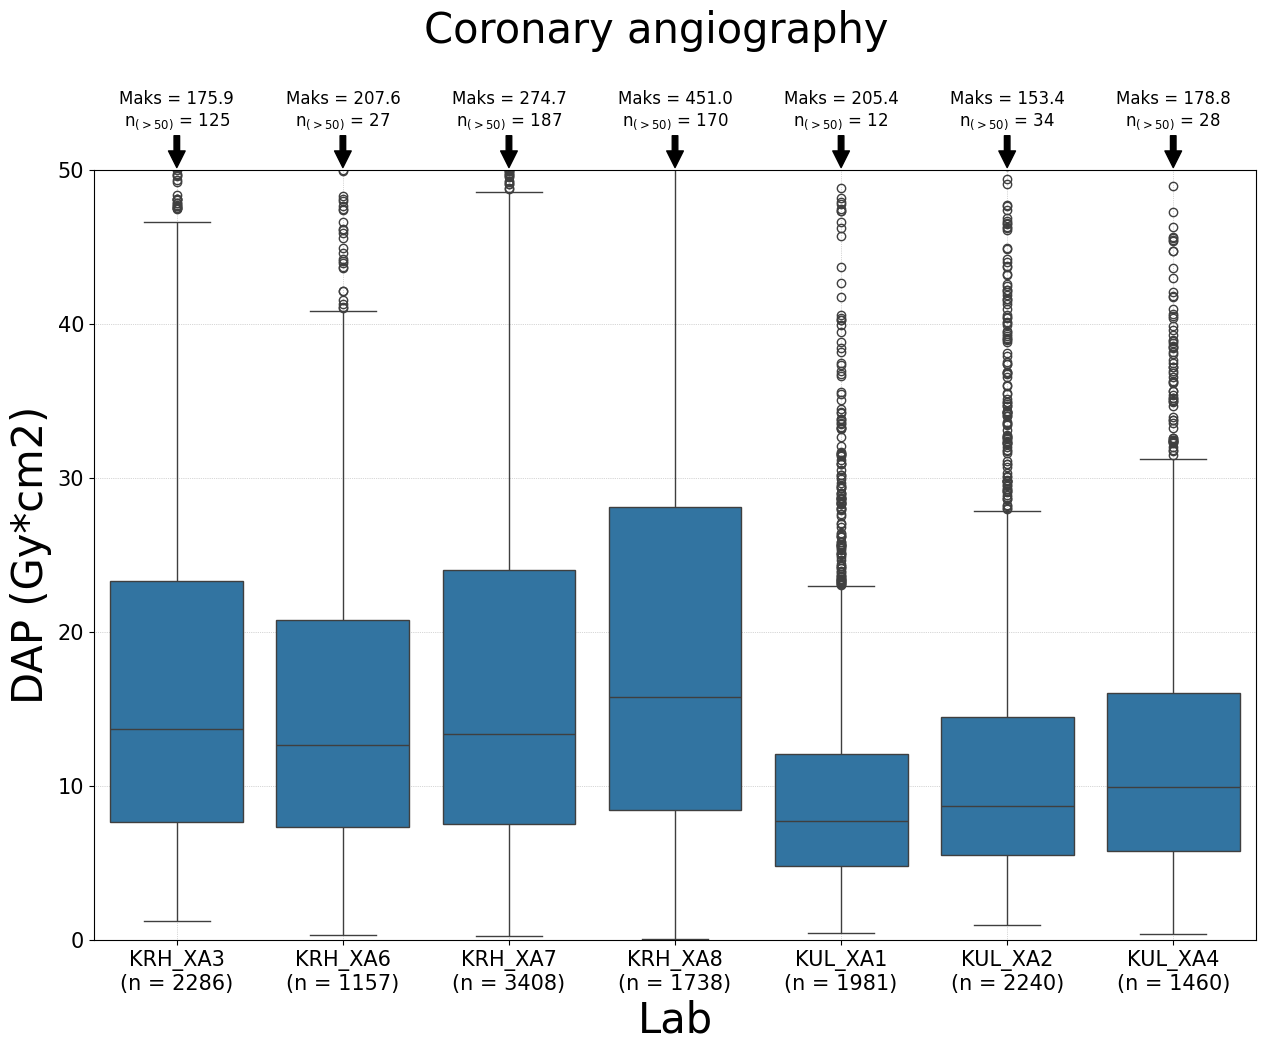

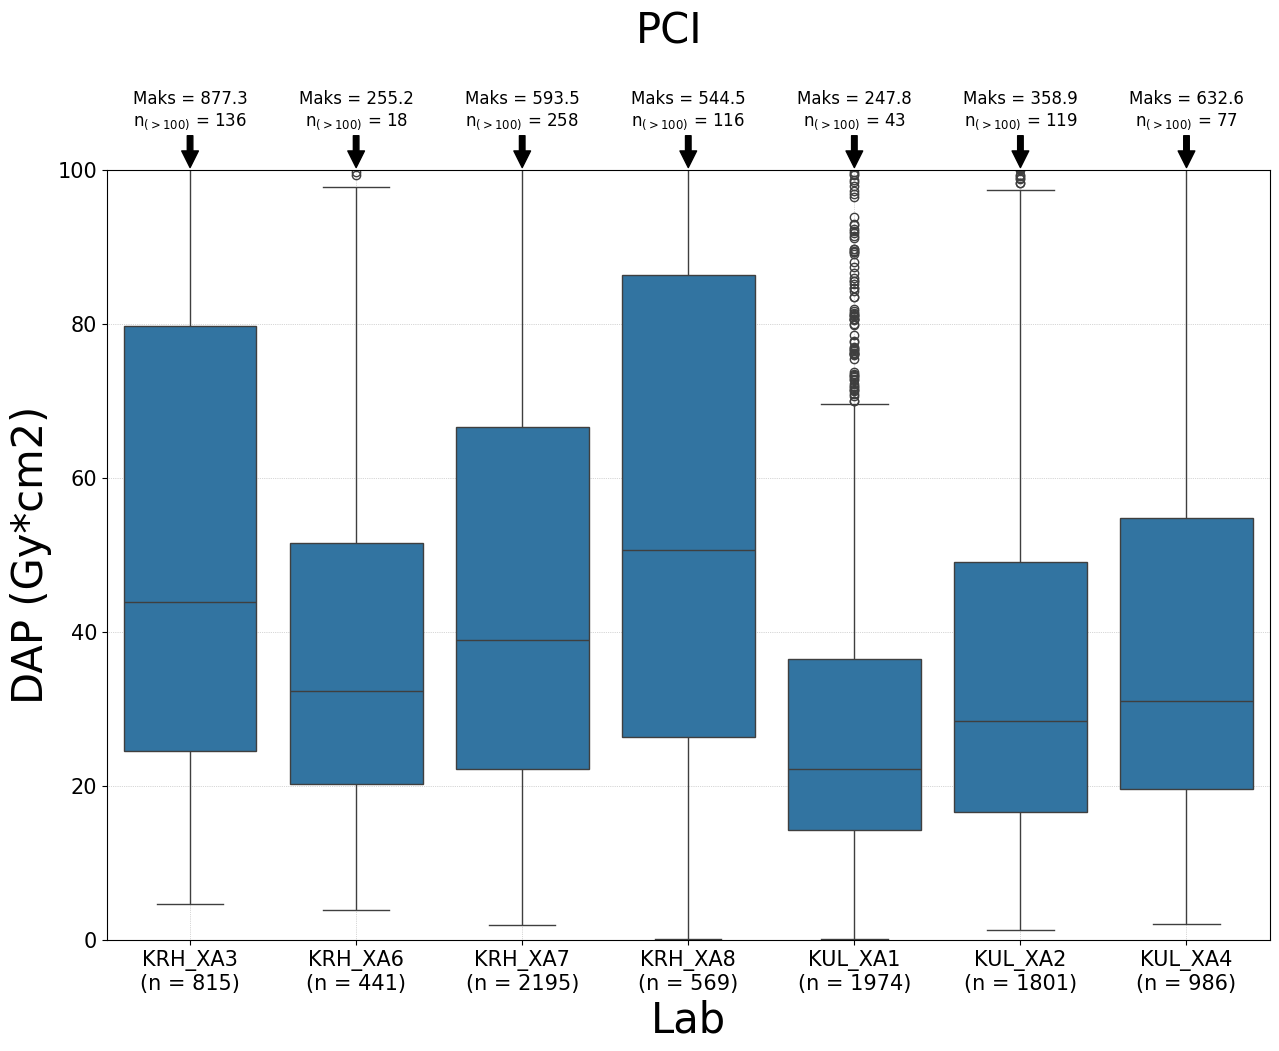

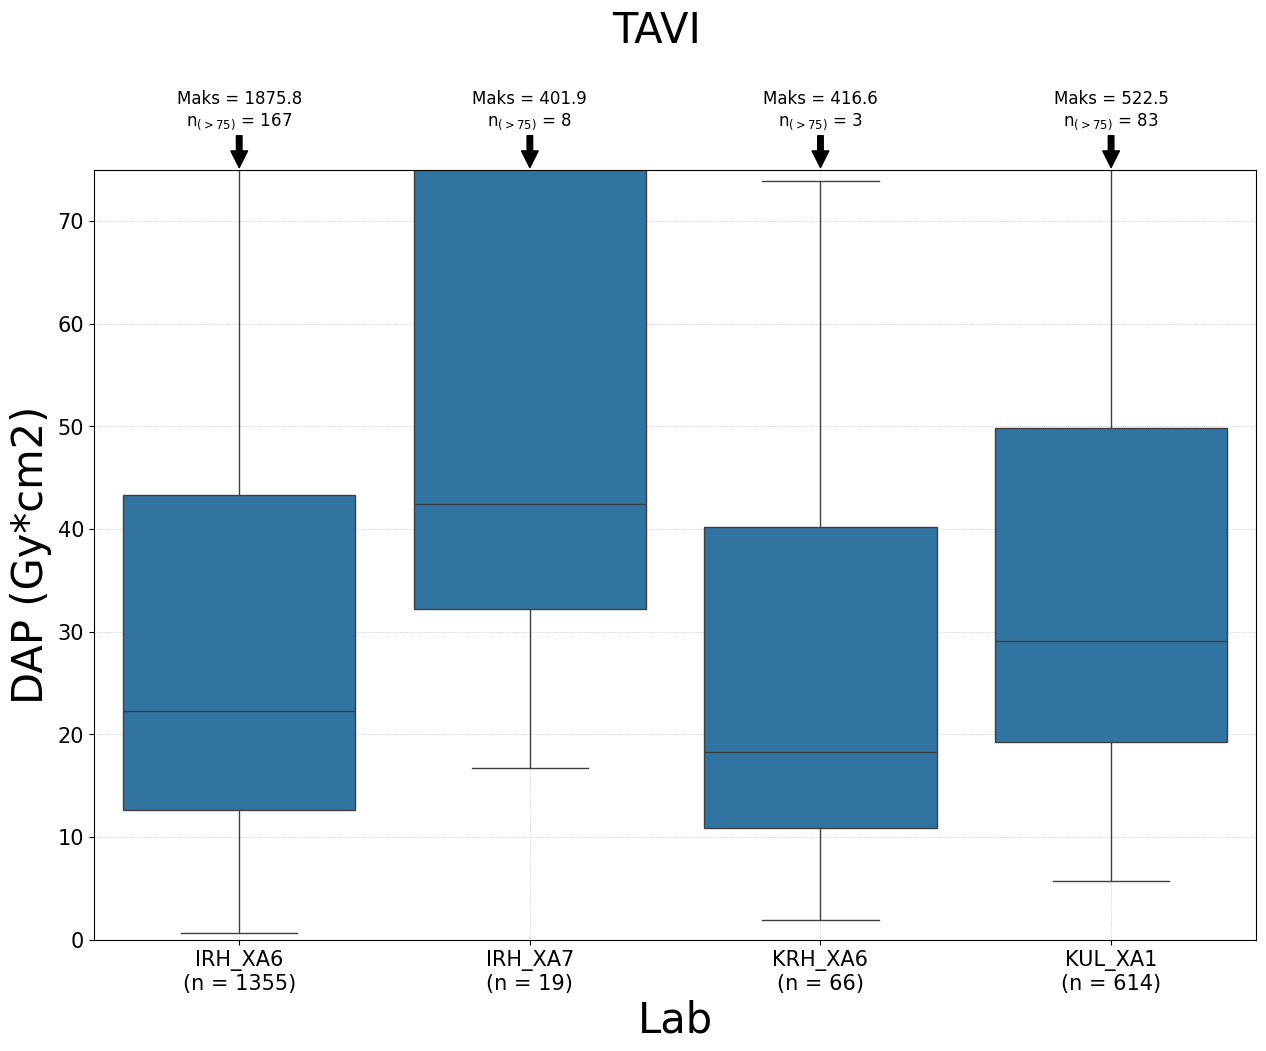

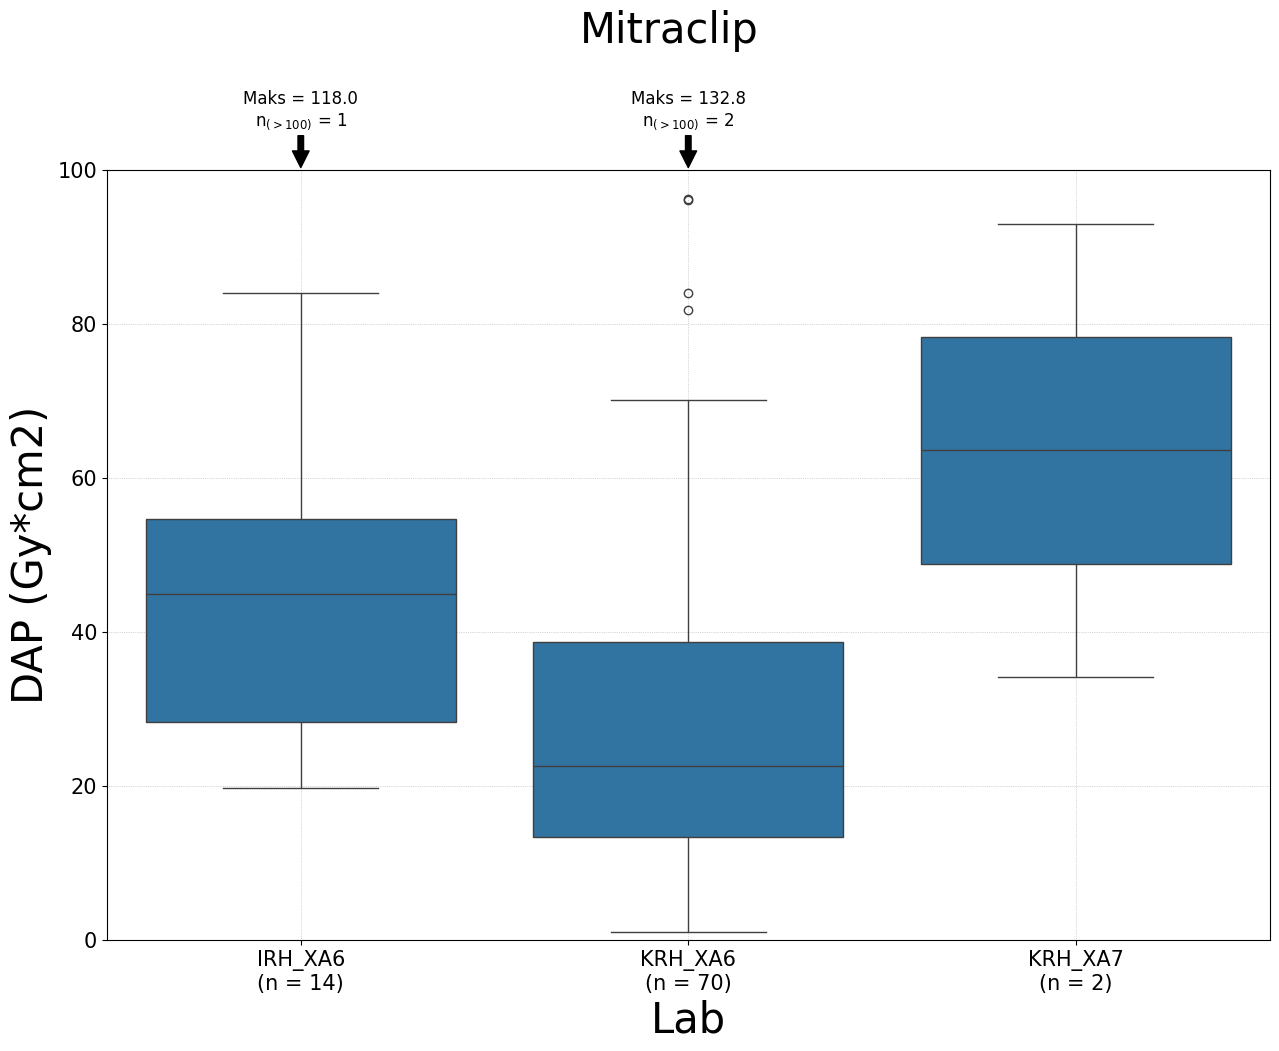

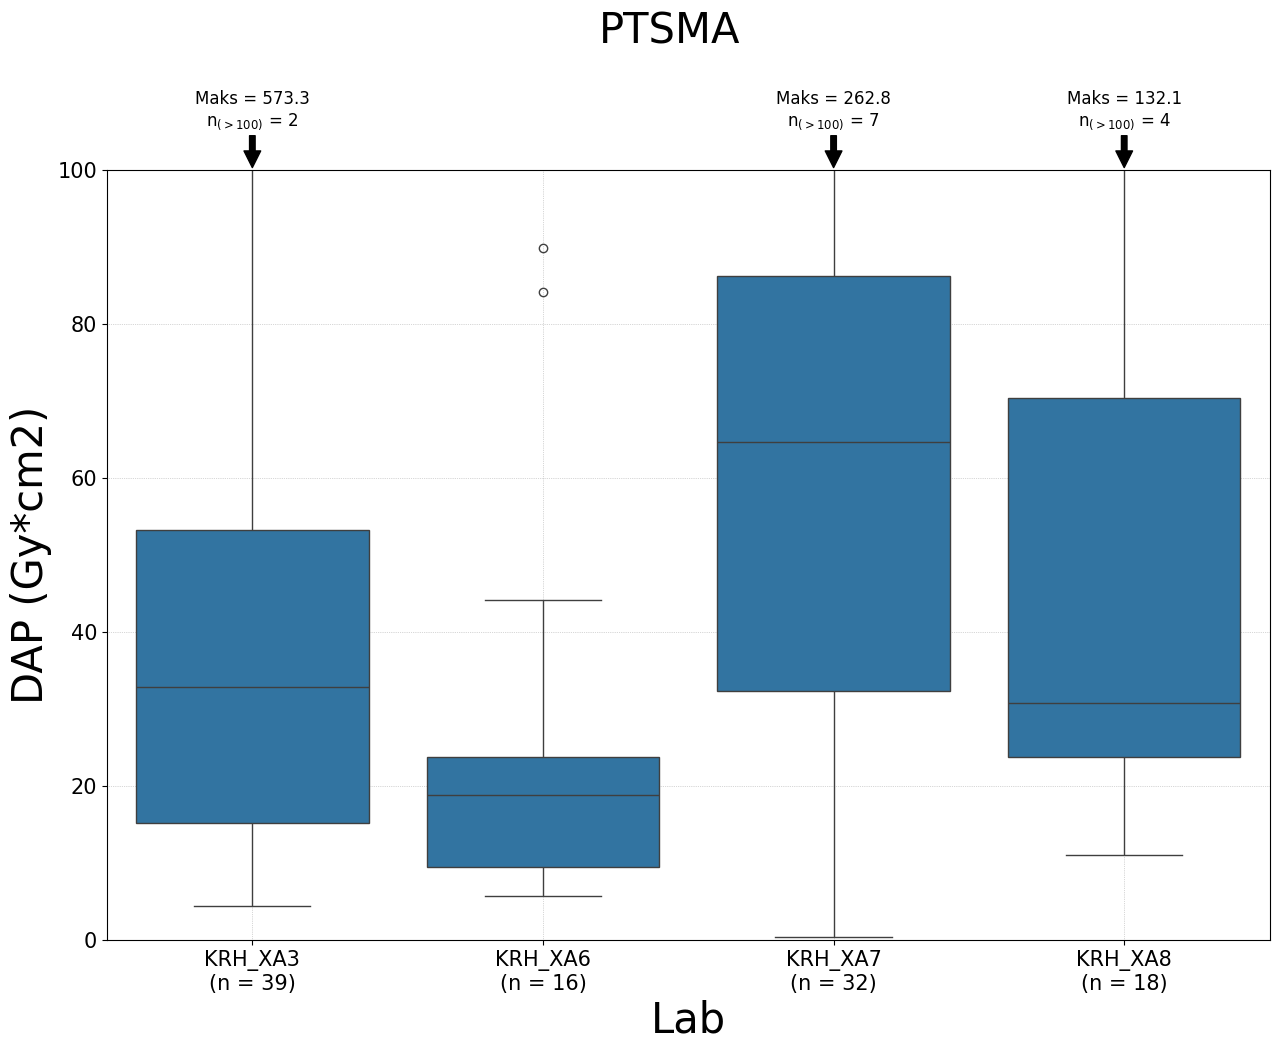

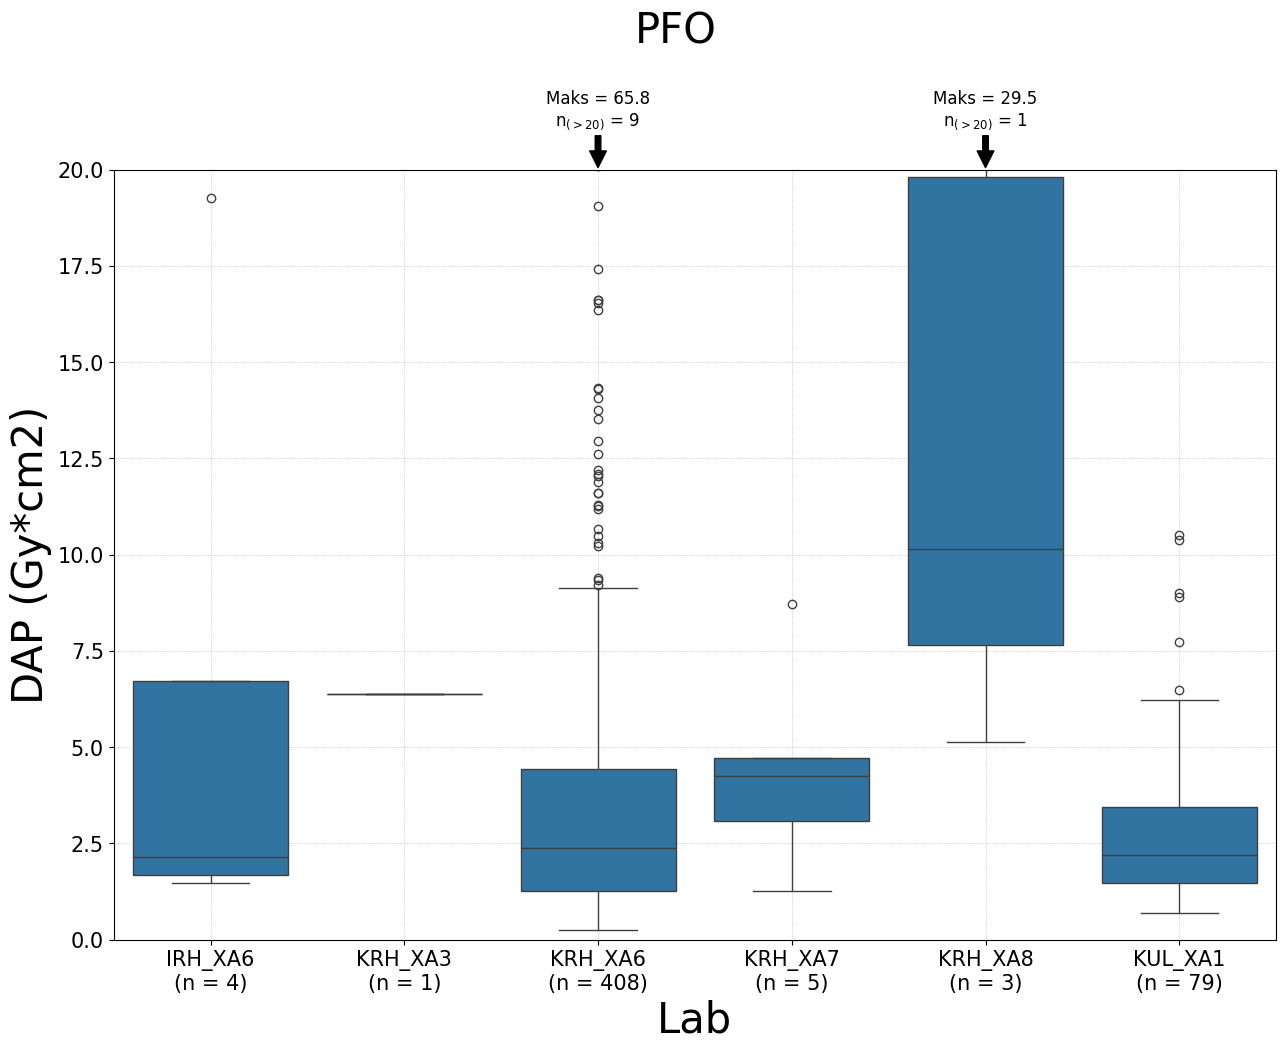

In [ ]:
from xa_dose_analysis import plot_module as bh_plot
from xa_dose_analysis import reporting_module as bh_report

importlib.reload(bh_plot)
importlib.reload(bh_report)
def run_analysis(data, procedure, y):
    export = False
    bh_plot.plot_representative_dose(data, procedure, y, export)
    print('\n')
    bh_report.report_exposure_time_all(data[data['Mapped Procedures'] == procedure], True)
    print('\n')
    bh_report.report_exposure_time_per_lab(data[data['Mapped Procedures'] == procedure], True)
    print('\n')
    print('###############################################')
    print('\n')
    


In [ ]:

run_analysis(data_pci, 'Coronary angiography', 50)
run_analysis(data_pci, 'PCI', 100)
run_analysis(data_pci, 'TAVI', 75)
